In [8]:
# makes more of things u give it
# lets load up a bunch of names from ./makemore/names.txt
path = './makemore/names.txt'
words = open(path, 'r').read().splitlines()
print('first 10 words: \t', words[:10],
      '\nnumber of words: \t', len(words),
      '\nsmallest word length: \t', min(len(w) for w in words),
      '\nbiggest word length: \t', max(len(w) for w in words))

first 10 words: 	 ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn'] 
number of words: 	 32033 
smallest word length: 	 2 
biggest word length: 	 15


In [13]:
print('bigrams of first word')
for w in words[:1]:
    for c1, c2 in zip(w, w[1:]):
        print(c1,c2)
        
print('\nbigrams of second word')
for w in words[1:2]:
    for c1, c2 in zip(w, w[1:]):
        print(c1,c2)

bigrams of first word
e m
m m
m a

bigrams of second word
o l
l i
i v
v i
i a


In [14]:
# lets hallucinate a hidden start and end bigram
for w in words[:1]:
    w = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(w, w[1:]):
        print(c1,c2)

<S> e
e m
m m
m a
a <E>


In [17]:
# lets start counting occurrences (frequency of bigrams)
bfreq = {}
for w in words[:3]: # first 3 words
    w = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(w, w[1:]):
        bigram = (c1,c2)
        bfreq[bigram] = bfreq.get(bigram, 0) + 1
        # print(c1,c2)

print(bfreq) # notice that bigram ('a', '<E>') occurs 3 times. Means that all 3 names ended with a's.
print(words[:3])

{('<S>', 'e'): 1, ('e', 'm'): 1, ('m', 'm'): 1, ('m', 'a'): 1, ('a', '<E>'): 3, ('<S>', 'o'): 1, ('o', 'l'): 1, ('l', 'i'): 1, ('i', 'v'): 1, ('v', 'i'): 1, ('i', 'a'): 1, ('<S>', 'a'): 1, ('a', 'v'): 1, ('v', 'a'): 1}
['emma', 'olivia', 'ava']


In [21]:
# lets calc for all words
bfreq = {}
for w in words:
    w = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(w, w[1:]):
        bigram = (c1,c2)
        bfreq[bigram] = bfreq.get(bigram, 0) + 1

In [23]:
# lets look into the bigrams
# reverse sort em
bfreq_sorted = sorted(bfreq.items(), key = lambda kv: -kv[1])
bfreq_sorted[:10]

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

In [47]:
# lets get it into a pytorch tensor

import torch
alphabet = sorted(list(set(''.join(words)))) + ['<S>', '<E>']
print(alphabet)
N = len(alphabet)  # 28 == Alphabet + two special encodings for start and end
M = N
shape = (N, M)
tensor = torch.zeros(shape, dtype=torch.int32)
tensor.shape

# create a reverse LUT for future use
# alphabet.index('a') # dont do this , create a lookup table for O(1)
atoi = { v:i for i,v in enumerate(alphabet) }
atoi['<S>'] = 26
atoi['<E>'] = 27

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '<S>', '<E>']


In [49]:
# lets put it into this tensor we created
for w in words:
    w = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        bigram = (c1,c2)
        tensor[atoi_c1, atoi_c2] += 1



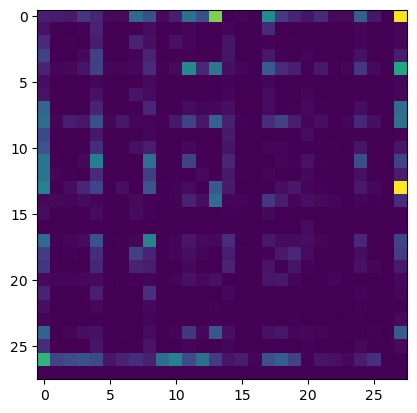

In [53]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(tensor)

(-0.5, 27.5, 27.5, -0.5)

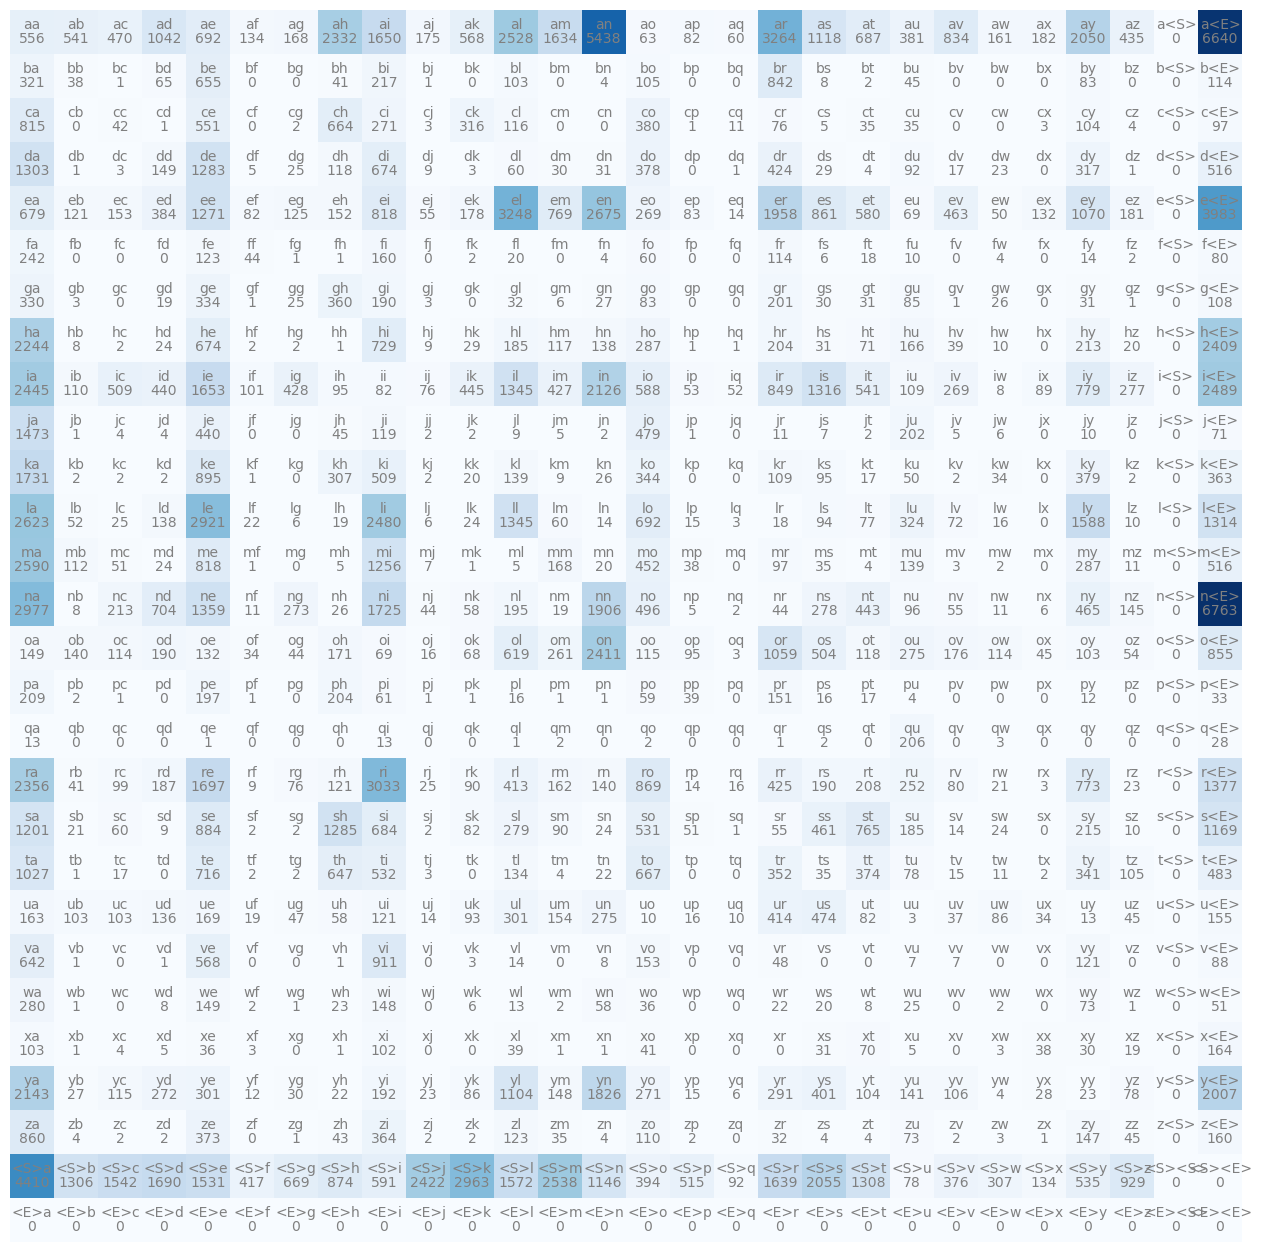

In [54]:
plt.figure(figsize=(16,16))
plt.imshow(tensor, cmap='Blues')
for i in range(N):
    for j in range(N):
        chstr = alphabet[i] + alphabet[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, tensor[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')
        